# Finetune PhoBERT Model — ViHOS Dataset
Finetune pre-trained PhoBERT với Layer-wise LR Decay, Warmup, Weight Decay, Label Smoothing

**Dataset**: ViHOS — Vietnamese Hate and Offensive Speech detection  
**Task**: Binary classification — `NONE` (label 0) vs `TOXIC` (label 1)  
**Label logic**: `index_spans == []` → NONE (0); `index_spans` non-empty → TOXIC (1)


## Improvements over pre ver
- **Model**: `phobert-base-v2` (trained on larger corpus including OSCAR data)
- **LLRD**: Layer-wise Learning Rate Decay (factor=0.95) — tránh catastrophic forgetting
- **Warmup**: 6% of total training steps — ổn định gradient đầu training
- **Weight Decay**: 0.01 (excluding bias & LayerNorm) — regularization
- **Fixed**: Deprecated `torch.cuda.amp` API warnings

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')
BASE_DIR = "/kaggle/input/datasets/truongpahm/datavihos/data"


In [2]:
# !pip install transformers torch datasets scikit-learn -q

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import re
import unicodedata
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import random

# --- Cấu hình thiết bị (Device Setup) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Đảm bảo kết quả có thể tái lập (Reproducibility) ---
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

print(f"Thiết bị đang sử dụng: {device}")

Thiết bị đang sử dụng: cuda


## Load Data

In [4]:
import ast

TRAIN_PATH = os.path.join(BASE_DIR, 'Span_Extraction_based_version', 'train.csv')
VAL_PATH   = os.path.join(BASE_DIR, 'Span_Extraction_based_version', 'dev.csv')
TEST_PATH  = os.path.join(BASE_DIR, 'Test_data', 'test.csv')


def parse_label(index_spans_str):
    """Chuyển index_spans thành nhãn nhị phân.
    [] (rỗng)    → 0 (NONE)
    [x, y, ...] → 1 (TOXIC)
    """
    try:
        spans = ast.literal_eval(str(index_spans_str))
        return 0 if len(spans) == 0 else 1
    except (ValueError, SyntaxError):
        return 0  # fallback: coi là NONE nếu parse thất bại


def load_vihos(path):
    """Đọc file CSV ViHOS và trả về DataFrame với cột label nhị phân."""
    df = pd.read_csv(path)
    df = df.dropna(subset=['content', 'index_spans'])
    df['label'] = df['index_spans'].apply(parse_label)
    return df


df_train = load_vihos(TRAIN_PATH)
df_val   = load_vihos(VAL_PATH)
df_test  = load_vihos(TEST_PATH)

X_train = df_train['content'].values
y_train = df_train['label'].values
X_val   = df_val['content'].values
y_val   = df_val['label'].values
X_test  = df_test['content'].values
y_test  = df_test['label'].values

LABEL_NAMES = {0: 'NONE', 1: 'TOXIC'}

print(f"Train samples: {len(X_train)}")
print(pd.Series(y_train).map(LABEL_NAMES).value_counts())
print(f"\nVal samples:   {len(X_val)}")
print(pd.Series(y_val).map(LABEL_NAMES).value_counts())
print(f"\nTest samples:  {len(X_test)}")
print(pd.Series(y_test).map(LABEL_NAMES).value_counts())


Train samples: 8844
NONE     4552
TOXIC    4292
Name: count, dtype: int64

Val samples:   1106
NONE     569
TOXIC    537
Name: count, dtype: int64

Test samples:  1106
NONE     575
TOXIC    531
Name: count, dtype: int64


## Data Info

In [5]:
# Data was already split into train/val/test in the data directory
print(f"Train set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

Train set size: 8844
Validation set size: 1106
Test set size: 1106


## Load Tokenizer and Model

In [6]:
model_name = "vinai/phobert-base-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

n_gpus = torch.cuda.device_count()
print(f"Loaded tokenizer from {model_name}")
print(f"Number of GPUs available: {n_gpus}")

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded tokenizer from vinai/phobert-base-v2
Number of GPUs available: 2


## Create Classification Model

In [ ]:
from transformers import AutoModelForSequenceClassification

num_classes = len(np.unique(y_train))
# Thay vì dùng class custom, ta dùng luôn sequence classification của HuggingFace để tiện lưu và load
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_classes)

if n_gpus > 1:
    model = nn.DataParallel(model)
model = model.to(device)

print(f"Model created with {num_classes} classes")
print(f"Using DataParallel: {isinstance(model, nn.DataParallel)}")

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

Model created with 2 classes
Using DataParallel: True


## Custom Dataset

In [8]:
MAX_LENGTH = 128
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(label, dtype=torch.long)
        }

print("Dataset class created")

Dataset class created


## Create DataLoaders

In [9]:
train_dataset = TextDataset(X_train, y_train, tokenizer)
val_dataset = TextDataset(X_val, y_val, tokenizer)
test_dataset = TextDataset(X_test, y_test, tokenizer)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train loader: {len(train_loader)} batches")
print(f"Val loader: {len(val_loader)} batches")
print(f"Test loader: {len(test_loader)} batches")

Train loader: 70 batches
Val loader: 9 batches
Test loader: 9 batches


## Training Setup

In [10]:
# ====================================================================
# LLRD (Layer-wise Learning Rate Decay) — Kỹ thuật quan trọng nhất
# ====================================================================
def get_optimizer_grouped_parameters(model, base_lr=2e-5, llrd_factor=0.95, weight_decay=0.01):
    """
    Gán learning rate khác nhau cho từng layer của PhoBERT.
    - Classifier head: lr cao nhất (base_lr * 3)
    - Encoder layer 11 (top): base_lr
    - Encoder layer 0 (bottom): base_lr * llrd_factor^11
    - Embeddings: base_lr * llrd_factor^12
    
    Bias và LayerNorm không áp dụng weight decay.
    """
    named_params = list(model.named_parameters())
    
    no_decay_keywords = ['bias', 'LayerNorm.weight', 'LayerNorm.bias']
    
    optimizer_grouped_parameters = []
    handled_param_ids = set()
    
    # --- Classifier head: lr cao nhất ---
    clf_decay = [p for n, p in named_params 
                 if 'classifier' in n 
                 and not any(nd in n for nd in no_decay_keywords) 
                 and p.requires_grad]
    clf_no_decay = [p for n, p in named_params 
                    if 'classifier' in n 
                    and any(nd in n for nd in no_decay_keywords) 
                    and p.requires_grad]
    
    if clf_decay:
        optimizer_grouped_parameters.append({
            'params': clf_decay, 'lr': base_lr * 3, 'weight_decay': weight_decay
        })
        handled_param_ids.update(id(p) for p in clf_decay)
    if clf_no_decay:
        optimizer_grouped_parameters.append({
            'params': clf_no_decay, 'lr': base_lr * 3, 'weight_decay': 0.0
        })
        handled_param_ids.update(id(p) for p in clf_no_decay)
    
    # --- Encoder layers 11 → 0: lr giảm dần ---
    for layer_num in range(11, -1, -1):
        layer_lr = base_lr * (llrd_factor ** (11 - layer_num))
        layer_key = f'encoder.layer.{layer_num}.'
        
        decay_params = [p for n, p in named_params 
                       if layer_key in n 
                       and not any(nd in n for nd in no_decay_keywords) 
                       and p.requires_grad]
        no_decay_params = [p for n, p in named_params 
                          if layer_key in n 
                          and any(nd in n for nd in no_decay_keywords) 
                          and p.requires_grad]
        
        if decay_params:
            optimizer_grouped_parameters.append({
                'params': decay_params, 'lr': layer_lr, 'weight_decay': weight_decay
            })
            handled_param_ids.update(id(p) for p in decay_params)
        if no_decay_params:
            optimizer_grouped_parameters.append({
                'params': no_decay_params, 'lr': layer_lr, 'weight_decay': 0.0
            })
            handled_param_ids.update(id(p) for p in no_decay_params)
    
    # --- Embeddings: lr thấp nhất ---
    embed_lr = base_lr * (llrd_factor ** 12)
    embed_decay = [p for n, p in named_params 
                   if 'embeddings' in n 
                   and not any(nd in n for nd in no_decay_keywords) 
                   and p.requires_grad]
    embed_no_decay = [p for n, p in named_params 
                      if 'embeddings' in n 
                      and any(nd in n for nd in no_decay_keywords) 
                      and p.requires_grad]
    
    if embed_decay:
        optimizer_grouped_parameters.append({
            'params': embed_decay, 'lr': embed_lr, 'weight_decay': weight_decay
        })
        handled_param_ids.update(id(p) for p in embed_decay)
    if embed_no_decay:
        optimizer_grouped_parameters.append({
            'params': embed_no_decay, 'lr': embed_lr, 'weight_decay': 0.0
        })
        handled_param_ids.update(id(p) for p in embed_no_decay)
    
    # --- Remaining params (pooler, etc.) ---
    other_params = [p for n, p in named_params 
                    if id(p) not in handled_param_ids and p.requires_grad]
    if other_params:
        optimizer_grouped_parameters.append({
            'params': other_params, 'lr': base_lr, 'weight_decay': 0.0
        })
    
    return optimizer_grouped_parameters

# ====================================================================
# Training Configuration
# ====================================================================
BASE_LR = 2e-5
LLRD_FACTOR = 0.95
WEIGHT_DECAY = 0.01

criterion = nn.CrossEntropyLoss()

# LLRD Optimizer
optimizer_params = get_optimizer_grouped_parameters(
    model, base_lr=BASE_LR, llrd_factor=LLRD_FACTOR, weight_decay=WEIGHT_DECAY
)
optimizer = AdamW(optimizer_params, lr=BASE_LR)

num_epochs = 10
total_steps = len(train_loader) * num_epochs

# Warmup 6% — ổn định gradient ở đầu training
num_warmup_steps = int(0.06 * total_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=total_steps
)

# Mixed precision (non-deprecated API)
use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

# Early stopping configuration
patience = 2
best_val_loss = float('inf')
early_stop_counter = 0
best_model_path = os.path.join('models', 'PhoBERT-v3', 'best_model.pt')
os.makedirs(os.path.dirname(best_model_path), exist_ok=True)

# Print config
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"=== Training Config (v3 - Optimized) ===")
print(f"Model: {model_name}")
print(f"Base LR: {BASE_LR}, LLRD factor: {LLRD_FACTOR}")
print(f"Weight Decay: {WEIGHT_DECAY}")
print(f"Warmup steps: {num_warmup_steps} / {total_steps} total ({num_warmup_steps/total_steps*100:.1f}%)")
print(f"Number of epochs: {num_epochs}")
print(f"Batch size: {batch_size}")
print(f"AMP enabled: {use_amp}")
print(f"Early stopping patience: {patience}")
print(f"Total trainable params: {total_params:,}")
print(f"Optimizer param groups: {len(optimizer_params)}")

=== Training Config (v3 - Optimized) ===
Model: vinai/phobert-base-v2
Base LR: 2e-05, LLRD factor: 0.95
Weight Decay: 0.01
Warmup steps: 42 / 700 total (6.0%)
Number of epochs: 10
Batch size: 128
AMP enabled: True
Early stopping patience: 2
Total trainable params: 134,999,810
Optimizer param groups: 29


## Training Function

In [ ]:
def train_epoch(model, data_loader, optimizer, scheduler, criterion, device, scaler):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in tqdm(data_loader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda', enabled=scaler.is_enabled()):
            # Lấy logits từ model (HuggingFace SequenceClassification trả về tuple khi return_dict=False)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, return_dict=False)
            logits = outputs[0]
            loss = criterion(logits, labels)

        if scaler.is_enabled():
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        scheduler.step()

        total_loss += loss.item()
        _, predictions = torch.max(logits, 1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(data_loader)
    avg_accuracy = correct / total

    return avg_loss, avg_accuracy

## Evaluation Function

In [ ]:
def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, return_dict=False)
                logits = outputs[0]
                loss = criterion(logits, labels)

            total_loss += loss.item()
            _, predictions = torch.max(logits, 1)

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)

    return avg_loss, all_preds, all_labels

## Train Model

In [13]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion, device, scaler)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Evaluate on validation set for early stopping
    val_loss, val_preds, val_labels = evaluate(model, val_loader, criterion, device)
    val_acc = accuracy_score(val_labels, val_preds)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Early stopping check (save best model)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0
        state_dict_to_save = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
        torch.save(state_dict_to_save, best_model_path)
        print(f"Validation loss improved. Saved best model to {best_model_path}")
    else:
        early_stop_counter += 1
        print(f"No improvement in val loss for {early_stop_counter} epoch(s)")

    if early_stop_counter >= patience:
        print(f"Early stopping triggered (patience={patience}).")
        break

# After training, load best model for final evaluation if it exists
if os.path.exists(best_model_path):
    model_to_load = model.module if isinstance(model, nn.DataParallel) else model
    model_to_load.load_state_dict(torch.load(best_model_path, map_location=device))
    print(f"Loaded best model from {best_model_path}")

print("\nTraining completed!")


Epoch 1/10



Evaluating: 100%|██████████| 9/9 [00:01<00:00,  5.58it/s]


Train Loss: 0.5461, Train Acc: 0.7107
Val Loss: 0.3225, Val Acc: 0.8617
Validation loss improved. Saved best model to models/PhoBERT-v3/best_model.pt

Epoch 2/10


Evaluating: 100%|██████████| 9/9 [00:01<00:00,  5.48it/s]


Train Loss: 0.3282, Train Acc: 0.8627
Val Loss: 0.2652, Val Acc: 0.8843
Validation loss improved. Saved best model to models/PhoBERT-v3/best_model.pt

Epoch 3/10


...

Train Loss: 0.2064, Train Acc: 0.9220
Val Loss: 0.2533, Val Acc: 0.9005
Validation loss improved. Saved best model to models/PhoBERT-v3/best_model.pt

Epoch 5/10


Evaluating: 100%|██████████| 9/9 [00:01<00:00,  5.45it/s]


Train Loss: 0.1761, Train Acc: 0.9346
Val Loss: 0.2619, Val Acc: 0.9024
No improvement in val loss for 1 epoch(s)

Epoch 6/10


Evaluating: 100%|██████████| 9/9 [00:01<00:00,  5.47it/s]


Train Loss: 0.1437, Train Acc: 0.9481
Val Loss: 0.2765, Val Acc: 0.9042
No improvement in val loss for 2 epoch(s)
Early stopping triggered (patience=2).
Loaded best model from models/PhoBERT-v3/best_model.pt

Training completed!


## Final Evaluation

In [14]:
test_loss, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

print("\n=== Test Set Metrics ===")
print(f"Accuracy: {accuracy_score(test_labels, test_preds):.4f}")
print(f"Precision: {precision_score(test_labels, test_preds, average='weighted'):.4f}")
print(f"Recall: {recall_score(test_labels, test_preds, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(test_labels, test_preds, average='weighted'):.4f}")

Evaluating: 100%|██████████| 9/9 [00:01<00:00,  5.31it/s]



=== Test Set Metrics ===
Accuracy: 0.9005
Precision: 0.9017
Recall: 0.9005
F1-Score: 0.9003


## Confusion Matrix

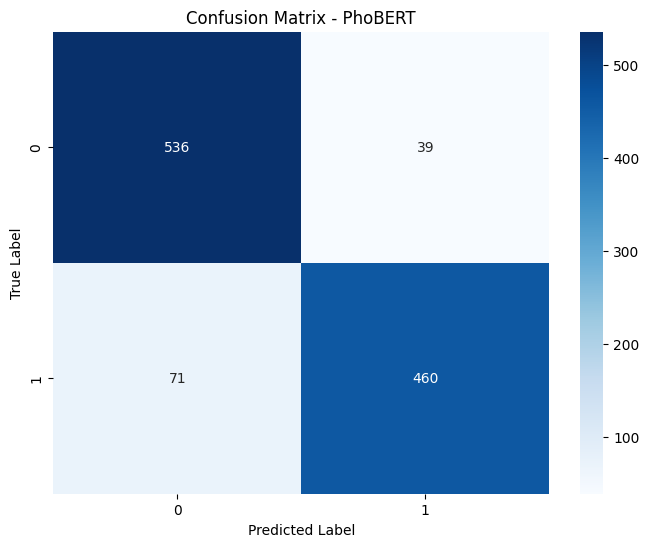

In [15]:
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - PhoBERT')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## Classification Report

In [16]:
print(classification_report(test_labels, test_preds))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91       575
           1       0.92      0.87      0.89       531

    accuracy                           0.90      1106
   macro avg       0.90      0.90      0.90      1106
weighted avg       0.90      0.90      0.90      1106



## Training History

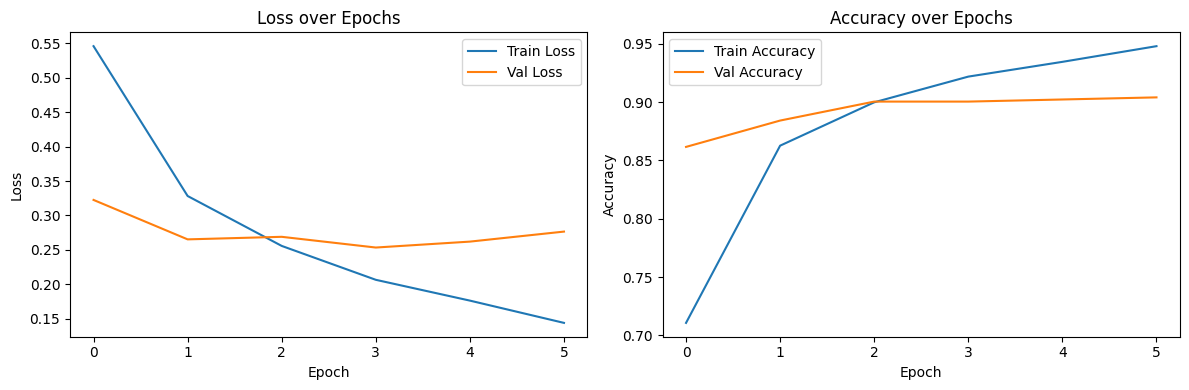

In [17]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

## Save Model

In [ ]:
model_dir = 'models/PhoBERT-v3'
os.makedirs(model_dir, exist_ok=True)

# Lấy model module gốc (bỏ bọc DataParallel nếu có)
model_to_save = model.module if isinstance(model, nn.DataParallel) else model

# Lưu dưới định dạng chuẩn Hugging Face (.safetensors và config.json)
model_to_save.save_pretrained(model_dir)
tokenizer.save_pretrained(model_dir)

print(f"Model saved to {model_dir}")
print("You can easily load it later using:")
print("AutoModelForSequenceClassification.from_pretrained('models/PhoBERT-v3')")

Model saved to models/PhoBERT-v3


## Tiền xử lý văn bản cho Transformer (Text Preprocessing Pipeline)
Khai báo các hàm tiền xử lý giống pipeline đã dùng khi tạo dữ liệu huấn luyện cho transformer,
đảm bảo dữ liệu đầu vào khi dự đoán thực tế được xử lý nhất quán.

**Lưu ý:** Pipeline cho transformer **khác** với LR/BiLSTM:
- Không loại bỏ dấu câu
- Không loại bỏ stopwords
- Không tách từ (pyvi)

In [19]:
# ---------- Regex patterns ----------
URL_PATTERN = r"http\S+|www\S+"
TAG_PATTERN = r"\[.*?\]"          # [hook], [quote], [img]...
HTML_PATTERN = r"<.*?>"
MENTION_PATTERN = r"@\w+"
HASHTAG_PATTERN = r"#(\w+)"

EMOJI_PATTERN = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F1E0-\U0001F1FF"  # flags (iOS)
    "]+",
    flags=re.UNICODE
)

FOREIGN_PATTERN = re.compile(
    "["
    "\u0370-\u04FF" "\u0600-\u06FF" "\u0E00-\u0E7F" "\u1780-\u17FF"
    "\u3040-\u30FF" "\u3130-\u318F" "\u4E00-\u9FFF" "\uAC00-\uD7AF"
    "]+", flags=re.UNICODE
)

REPEAT_PATTERN = r'(.)\1{2,}'     # giảm lặp ký tự


def reduce_repeated_chars(text: str) -> str:
    """Giảm lặp ký tự (giữ tối đa 2 lần)."""
    return re.sub(REPEAT_PATTERN, r'\1\1', text)


def normalize_unicode(text: str) -> str:
    """Chuẩn hóa Unicode về dạng tổ hợp (NFC)."""
    return unicodedata.normalize('NFC', text)

In [20]:
def clean_text_for_transformer(text: str) -> str:
    """Tiền xử lý cho transformer (PhoBERT). Không loại bỏ dấu câu."""
    if not isinstance(text, str):
        return ""

    # 1. Chuẩn hóa Unicode
    text = normalize_unicode(text)

    # 2. Loại bỏ kí tự không thuộc tiếng việt
    text = re.sub(FOREIGN_PATTERN, "", text)

    # 3. Loại bỏ mention
    text = re.sub(MENTION_PATTERN, "", text)

    # 4. Xử lý hashtag: giữ phần từ, bỏ #
    text = re.sub(HASHTAG_PATTERN, r'\1', text)

    # 5. Loại bỏ URL, tag, HTML
    text = re.sub(URL_PATTERN, "", text)
    text = re.sub(TAG_PATTERN, "", text)
    text = re.sub(HTML_PATTERN, "", text)

    # 6. Loại bỏ emoji
    text = EMOJI_PATTERN.sub("", text)

    # 7. KHÔNG loại bỏ dấu câu (khác với pipeline cho LR/BiLSTM)

    # 8. Giảm lặp kí tự
    text = reduce_repeated_chars(text)

    # 9. Chuẩn hóa khoảng trắng
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [21]:
def nlp_processing_pipeline_for_transformer(text):
    """
    Pipeline tiền xử lý văn bản cho PhoBERT.
    Không loại bỏ dấu câu, không loại bỏ stopwords, không tokenize pyvi.

    Args:
        text (str): Văn bản đầu vào (raw).
    Returns:
        str: Văn bản đã được xử lý.
    """

    # --- Bước 1: Kiểm tra & Lowercasing ---
    if not isinstance(text, str):
        return ""
    text = text.lower()

    # --- Bước 2: Chuẩn hóa văn bản, bỏ tag, html tag, url ---
    text = clean_text_for_transformer(text)

    # --- KHÔNG remove stopwords (transformer tự xử lý context) ---
    # --- KHÔNG tokenize pyvi (PhoBERT có tokenizer riêng) ---

    return text


# Kiểm tra nhanh
sample = "Dm thằng này ngu vãi @user123 😂😂 https://example.com"
print(f"Raw:       {sample}")
print(f"Processed: {nlp_processing_pipeline_for_transformer(sample)}")

Raw:       Dm thằng này ngu vãi @user123 😂😂 https://example.com
Processed: dm thằng này ngu vãi


## Prediction Example

In [ ]:
LABEL_MAP = {0: 'NONE', 1: 'TOXIC'}


def predict_text(text, tokenizer, model, device):
    """Dự đoán văn bản thực tế: tiền xử lý → PhoBERT tokenizer → dự đoán."""
    # Tiền xử lý văn bản trước khi dự đoán
    processed = nlp_processing_pipeline_for_transformer(text)

    model.eval()
    encoding = tokenizer(
        processed,
        max_length=MAX_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, return_dict=False)
        logits = outputs[0]
        proba = torch.softmax(logits, dim=1)
        prediction = torch.argmax(logits, dim=1)

    return prediction.item(), proba.cpu().numpy()[0], processed


test_texts = [
    "Tôi rất thích sản phẩm này",
    "Tệ lắm, không thích chút nào",
    "Dm thằng ngu vãi, biết gì mà nói",
    "Bài viết rất hay và bổ ích, cảm ơn bạn!",
]

for text in test_texts:
    pred, proba, processed = predict_text(text, tokenizer, model, device)
    print(f"Raw text:      {text}")
    print(f"Processed:     {processed}")
    print(f"Prediction:    {pred} ({LABEL_MAP.get(pred, pred)})")
    print(f"Probability:   NONE={proba[0]:.4f}, TOXIC={proba[1]:.4f}")
    print()

Raw text:      Tôi rất thích sản phẩm này
Processed:     tôi rất thích sản phẩm này
Prediction:    0 (NONE)
Probability:   NONE=0.9844, TOXIC=0.0156

Raw text:      Tệ lắm, không thích chút nào
Processed:     tệ lắm, không thích chút nào
Prediction:    0 (NONE)
Probability:   NONE=0.7947, TOXIC=0.2053

Raw text:      Dm thằng ngu vãi, biết gì mà nói
Processed:     dm thằng ngu vãi, biết gì mà nói
Prediction:    1 (TOXIC)
Probability:   NONE=0.0065, TOXIC=0.9935

Raw text:      Bài viết rất hay và bổ ích, cảm ơn bạn!
Processed:     bài viết rất hay và bổ ích, cảm ơn bạn!
Prediction:    0 (NONE)
Probability:   NONE=0.9827, TOXIC=0.0173

